In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

In [2]:
# 2. Load the necessary packages
import pandas, numpy, torch, matplotlib
for m in (pandas, numpy, torch, matplotlib):
    print(m.__name__, m.__version__)

import pandas as pd, numpy as np
from pathlib import Path
import glob
import os
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

pandas 2.3.3
numpy 2.0.2
torch 2.10.0+cu128
matplotlib 3.10.0


In [3]:
# 3. Define data paths
train_path = "/kaggle/input/competitions/rogii-wellbore-geology-prediction/train"
test_path = "/kaggle/input/competitions/rogii-wellbore-geology-prediction/test"

In [4]:
#4. Load and combine the files
def load_data(path):
    # Match horizontal files
    hz_files = sorted(
        glob.glob(os.path.join(path, "*__horizontal_well.csv"))
    )

    # Match any filename containing "__typewell"
    tw_files = sorted(
        glob.glob(os.path.join(path, "*__typewell*.csv"))
    )

    print(f"Path: {path}")
    print(f"Horizontal files found: {len(hz_files)}")
    print(f"Typewell files found: {len(tw_files)}")

    if len(hz_files) == 0:
        raise FileNotFoundError(
            f"No horizontal-well files found in: {path}"
        )

    if len(tw_files) == 0:
        raise FileNotFoundError(
            f"No typewell files found in: {path}"
        )

    hz_list = []
    tw_list = []

    for file in hz_files:
        df = pd.read_csv(file)

        well_id = os.path.basename(file).split("__")[0]

        df["well_id"] = well_id
        df["row_index"] = np.arange(len(df))
        df["source_file"] = os.path.basename(file)

        hz_list.append(df)

    for file in tw_files:
        df = pd.read_csv(file)

        well_id = os.path.basename(file).split("__")[0]

        df["well_id"] = well_id
        df["typewell_row_index"] = np.arange(len(df))
        df["source_file"] = os.path.basename(file)

        tw_list.append(df)

    combined_hz = pd.concat(hz_list, ignore_index=True)
    combined_tw = pd.concat(tw_list, ignore_index=True)

    return combined_hz, combined_tw


hz_train, tw_train = load_data(train_path)
hz_test, tw_test = load_data(test_path)

Path: /kaggle/input/competitions/rogii-wellbore-geology-prediction/train
Horizontal files found: 773
Typewell files found: 773
Path: /kaggle/input/competitions/rogii-wellbore-geology-prediction/test
Horizontal files found: 3
Typewell files found: 3


In [5]:
# 5. Check the merged files
print("HORIZONTAL Train:", hz_train.shape)
display(hz_train.head())

print("TYPEWELL Train:", tw_train.shape)
display(tw_train.head())

print("HORIZONTAL Test:", hz_test.shape)
display(hz_test.head())

print("TYPEWELL Test:", tw_test.shape)
display(tw_test.head())

HORIZONTAL Train: (5092255, 16)


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,well_id,row_index,source_file
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02,000d7d20,0,000d7d20__horizontal_well.csv
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05,000d7d20,1,000d7d20__horizontal_well.csv
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09,000d7d20,2,000d7d20__horizontal_well.csv
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12,000d7d20,3,000d7d20__horizontal_well.csv
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15,000d7d20,4,000d7d20__horizontal_well.csv


TYPEWELL Train: (1567045, 6)


,TVT,GR,Geology,well_id,typewell_row_index,source_file
0,11223.95,126.11,NaN,000d7d20,0,000d7d20__typewell.csv
1,11224.45,128.22,NaN,000d7d20,1,000d7d20__typewell.csv
2,11224.95,128.72,NaN,000d7d20,2,000d7d20__typewell.csv
3,11225.45,128.12,NaN,000d7d20,3,000d7d20__typewell.csv
4,11225.95,125.29,NaN,000d7d20,4,000d7d20__typewell.csv


HORIZONTAL Test: (19221, 9)


,MD,X,Y,Z,GR,TVT_input,well_id,row_index,source_file
0,11467.0,2983525.16,1069022.09,-9258.57,115.692586,11236.02,000d7d20,0,000d7d20__horizontal_well.csv
1,11468.0,2983525.18,1069022.30,-9259.55,115.584293,11237.05,000d7d20,1,000d7d20__horizontal_well.csv
2,11469.0,2983525.20,1069022.52,-9260.52,135.446960,11238.09,000d7d20,2,000d7d20__horizontal_well.csv
3,11470.0,2983525.22,1069022.73,-9261.50,140.401346,11239.12,000d7d20,3,000d7d20__horizontal_well.csv
4,11471.0,2983525.25,1069022.95,-9262.47,111.270638,11240.15,000d7d20,4,000d7d20__horizontal_well.csv


TYPEWELL Test: (5798, 5)


,TVT,GR,well_id,typewell_row_index,source_file
0,11223.95,126.11,000d7d20,0,000d7d20__typewell.csv
1,11224.45,128.22,000d7d20,1,000d7d20__typewell.csv
2,11224.95,128.72,000d7d20,2,000d7d20__typewell.csv
3,11225.45,128.12,000d7d20,3,000d7d20__typewell.csv
4,11225.95,125.29,000d7d20,4,000d7d20__typewell.csv


In [6]:
# 6. Check the basic dataset structure
datasets = {
    "hz_train": hz_train,
    "tw_train": tw_train,
    "hz_test": hz_test,
    "tw_test": tw_test
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head())


hz_train
Shape: (5092255, 16)
Columns: ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input', 'well_id', 'row_index', 'source_file']


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,well_id,row_index,source_file
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02,000d7d20,0,000d7d20__horizontal_well.csv
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05,000d7d20,1,000d7d20__horizontal_well.csv
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09,000d7d20,2,000d7d20__horizontal_well.csv
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12,000d7d20,3,000d7d20__horizontal_well.csv
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15,000d7d20,4,000d7d20__horizontal_well.csv



tw_train
Shape: (1567045, 6)
Columns: ['TVT', 'GR', 'Geology', 'well_id', 'typewell_row_index', 'source_file']


,TVT,GR,Geology,well_id,typewell_row_index,source_file
0,11223.95,126.11,NaN,000d7d20,0,000d7d20__typewell.csv
1,11224.45,128.22,NaN,000d7d20,1,000d7d20__typewell.csv
2,11224.95,128.72,NaN,000d7d20,2,000d7d20__typewell.csv
3,11225.45,128.12,NaN,000d7d20,3,000d7d20__typewell.csv
4,11225.95,125.29,NaN,000d7d20,4,000d7d20__typewell.csv



hz_test
Shape: (19221, 9)
Columns: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input', 'well_id', 'row_index', 'source_file']


,MD,X,Y,Z,GR,TVT_input,well_id,row_index,source_file
0,11467.0,2983525.16,1069022.09,-9258.57,115.692586,11236.02,000d7d20,0,000d7d20__horizontal_well.csv
1,11468.0,2983525.18,1069022.30,-9259.55,115.584293,11237.05,000d7d20,1,000d7d20__horizontal_well.csv
2,11469.0,2983525.20,1069022.52,-9260.52,135.446960,11238.09,000d7d20,2,000d7d20__horizontal_well.csv
3,11470.0,2983525.22,1069022.73,-9261.50,140.401346,11239.12,000d7d20,3,000d7d20__horizontal_well.csv
4,11471.0,2983525.25,1069022.95,-9262.47,111.270638,11240.15,000d7d20,4,000d7d20__horizontal_well.csv



tw_test
Shape: (5798, 5)
Columns: ['TVT', 'GR', 'well_id', 'typewell_row_index', 'source_file']


,TVT,GR,well_id,typewell_row_index,source_file
0,11223.95,126.11,000d7d20,0,000d7d20__typewell.csv
1,11224.45,128.22,000d7d20,1,000d7d20__typewell.csv
2,11224.95,128.72,000d7d20,2,000d7d20__typewell.csv
3,11225.45,128.12,000d7d20,3,000d7d20__typewell.csv
4,11225.95,125.29,000d7d20,4,000d7d20__typewell.csv


In [7]:
# 7. Data Types
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.dtypes)


hz_train
MD             float64
X              float64
Y              float64
Z              float64
ANCC           float64
ASTNU          float64
ASTNL          float64
EGFDU          float64
EGFDL          float64
BUDA           float64
TVT            float64
GR             float64
TVT_input      float64
well_id         object
row_index        int64
source_file     object
dtype: object

tw_train
TVT                   float64
GR                    float64
Geology                object
well_id                object
typewell_row_index      int64
source_file            object
dtype: object

hz_test
MD             float64
X              float64
Y              float64
Z              float64
GR             float64
TVT_input      float64
well_id         object
row_index        int64
source_file     object
dtype: object

tw_test
TVT                   float64
GR                    float64
well_id                object
typewell_row_index      int64
source_file            object
dtype: object


In [8]:
# 8. Number of unique wells
for name, df in datasets.items():
    print(f"{name}: {df['well_id'].nunique()} unique well IDs")

hz_train: 773 unique well IDs
tw_train: 773 unique well IDs
hz_test: 3 unique well IDs
tw_test: 3 unique well IDs


In [9]:
# 8b. Make sure hz training well has a matching typewell
hz_train_ids = set(hz_train["well_id"])
tw_train_ids = set(tw_train["well_id"])

print("Same training well IDs:", hz_train_ids == tw_train_ids)
print("Missing typewells:", hz_train_ids - tw_train_ids)
print("Extra typewells:", tw_train_ids - hz_train_ids)

Same training well IDs: True
Missing typewells: set()
Extra typewells: set()


In [10]:
# 8c. Check the test data as well
hz_test_ids = set(hz_test["well_id"])
tw_test_ids = set(tw_test["well_id"])

print("Same test well IDs:", hz_test_ids == tw_test_ids)

Same test well IDs: True


In [11]:
#9 Check rows per well
hz_rows_per_well = hz_train.groupby("well_id").size()
tw_rows_per_well = tw_train.groupby("well_id").size()

print("Horizontal-well lengths")
display(hz_rows_per_well.describe())

print("Typewell lengths")
display(tw_rows_per_well.describe())

Horizontal-well lengths


count      773.000000
mean      6587.652005
std       1311.463547
min       2058.000000
25%       5706.000000
50%       6576.000000
75%       7388.000000
max      12141.000000
dtype: float64

Typewell lengths


count      773.000000
mean      2027.225097
std       1009.473248
min        636.000000
25%       1498.000000
50%       1874.000000
75%       2158.000000
max      10043.000000
dtype: float64

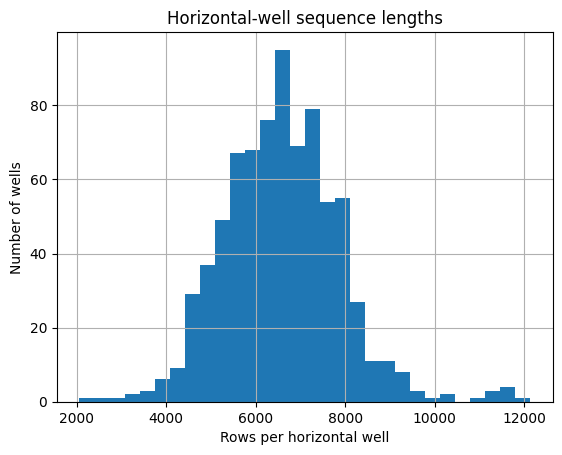

In [12]:
#10 Plot the horizontal-well lengths
hz_rows_per_well.hist(bins=30)

plt.xlabel("Rows per horizontal well")
plt.ylabel("Number of wells")
plt.title("Horizontal-well sequence lengths")
plt.show()

In [13]:
#11a. Summary statistics
for name, df in datasets.items():
    print(f"\n{name}")
    display(df.describe().T)


hz_train


,count,mean,std,min,25%,50%,75%,max
MD,5092255.0,1.431686e+04,2206.523850,9.335000e+03,1.254700e+04,1.419900e+04,1.592800e+04,2.296400e+04
X,5092255.0,2.965999e+06,47749.981497,2.855426e+06,2.917842e+06,2.986284e+06,3.006569e+06,3.039107e+06
Y,5092255.0,1.074748e+06,35603.540240,1.007176e+06,1.040716e+06,1.080803e+06,1.105967e+06,1.141858e+06
Z,5092255.0,-9.390812e+03,634.475915,-1.102765e+04,-9.920910e+03,-9.270310e+03,-8.918930e+03,-7.174220e+03
ANCC,5046621.0,-9.008724e+03,637.622279,-1.064731e+04,-9.548060e+03,-8.865570e+03,-8.511810e+03,-7.301760e+03
ASTNU,5092255.0,-9.192691e+03,641.864443,-1.085279e+04,-9.723750e+03,-9.063210e+03,-8.691070e+03,-7.509200e+03
ASTNL,5092255.0,-9.257051e+03,626.879708,-1.086558e+04,-9.771820e+03,-9.134010e+03,-8.765320e+03,-7.614430e+03
EGFDU,5092255.0,-9.350495e+03,621.995283,-1.088758e+04,-9.883505e+03,-9.213220e+03,-8.860120e+03,-7.704030e+03
EGFDL,5086188.0,-9.392205e+03,622.220203,-1.093235e+04,-9.925562e+03,-9.256610e+03,-8.902370e+03,-7.731610e+03
BUDA,5092255.0,-9.516918e+03,636.402653,-1.110473e+04,-1.005426e+04,-9.377050e+03,-9.017110e+03,-7.835570e+03



tw_train


,count,mean,std,min,25%,50%,75%,max
TVT,1567045.0,11234.144729,721.858283,9232.65,10713.13,11173.19,11809.12,12991.53
GR,1567045.0,89.091801,33.722934,18.53,64.66,89.73,110.68,433.58
typewell_row_index,1567045.0,1264.125116,1183.623102,0.00,506.00,1019.00,1620.00,10042.00



hz_test


,count,mean,std,min,25%,50%,75%,max
MD,19221.0,1.444556e+04,2051.403659,1.045600e+04,1.276800e+04,1.437000e+04,1.597200e+04,1.913600e+04
X,19221.0,2.988709e+06,16865.398448,2.967726e+06,2.970540e+06,2.983526e+06,3.007759e+06,3.010760e+06
Y,19221.0,1.074573e+06,10628.101791,1.060431e+06,1.063829e+06,1.071992e+06,1.086229e+06,1.089521e+06
Z,19221.0,-9.665867e+03,394.946757,-1.018258e+04,-1.005800e+04,-9.698160e+03,-9.302140e+03,-8.356040e+03
GR,15437.0,7.645979e+01,30.490246,2.189287e+01,4.567239e+01,8.304343e+01,9.730205e+01,2.198068e+02
TVT_input,5070.0,1.162665e+04,365.219697,1.060618e+04,1.145583e+04,1.160031e+04,1.175567e+04,1.222505e+04
row_index,19221.0,3.270694e+03,1962.572452,0.000000e+00,1.601000e+03,3.203000e+03,4.805000e+03,7.558000e+03



tw_test


,count,mean,std,min,25%,50%,75%,max
TVT,5798.0,11520.600655,417.802494,10593.95,11271.075,11553.700,11795.325,12366.95
GR,5798.0,91.822915,26.027917,28.66,74.730,99.275,109.210,215.44
typewell_row_index,5798.0,1034.310969,661.879755,0.00,483.000,966.000,1525.750,2555.00


In [14]:
#11b. Look at horizontal variables
horizontal_cols = ["MD", "X", "Y", "Z", "GR", "TVT_input"]

available_cols = [
    col for col in horizontal_cols
    if col in hz_train.columns
]

display(hz_train[available_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
MD,5092255.0,1.431686e+04,2206.523850,9.335000e+03,1.254700e+04,1.419900e+04,1.592800e+04,2.296400e+04
X,5092255.0,2.965999e+06,47749.981497,2.855426e+06,2.917842e+06,2.986284e+06,3.006569e+06,3.039107e+06
Y,5092255.0,1.074748e+06,35603.540240,1.007176e+06,1.040716e+06,1.080803e+06,1.105967e+06,1.141858e+06
Z,5092255.0,-9.390812e+03,634.475915,-1.102765e+04,-9.920910e+03,-9.270310e+03,-8.918930e+03,-7.174220e+03
GR,3584283.0,8.775241e+01,23.768335,1.388016e+01,7.249096e+01,8.585950e+01,1.010383e+02,4.870329e+02
TVT_input,1308266.0,1.138214e+04,663.171131,9.245190e+03,1.090497e+04,1.122422e+04,1.194713e+04,1.287730e+04


In [15]:
#12. Missing value analysis
def missing_summary(df):
    result = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100
    })

    return result.sort_values(
        "missing_percent",
        ascending=False
    )
for name, df in datasets.items():
    print(f"\n{name}")
    display(missing_summary(df))


hz_train


,missing_count,missing_percent
TVT_input,3783989,74.308710
GR,1507972,29.613050
ANCC,45634,0.896145
EGFDL,6067,0.119142
Z,0,0.000000
MD,0,0.000000
Y,0,0.000000
X,0,0.000000
EGFDU,0,0.000000
ASTNL,0,0.000000



tw_train


,missing_count,missing_percent
Geology,523474,33.405167
TVT,0,0.000000
GR,0,0.000000
well_id,0,0.000000
typewell_row_index,0,0.000000
source_file,0,0.000000



hz_test


,missing_count,missing_percent
TVT_input,14151,73.622600
GR,3784,19.686801
MD,0,0.000000
Y,0,0.000000
X,0,0.000000
Z,0,0.000000
well_id,0,0.000000
row_index,0,0.000000
source_file,0,0.000000



tw_test


,missing_count,missing_percent
TVT,0,0.0
GR,0,0.0
well_id,0,0.0
typewell_row_index,0,0.0
source_file,0,0.0


prediction_zone
True     3783989
False    1308266
Name: count, dtype: int64
prediction_zone
True     14151
False     5070
Name: count, dtype: int64


count    773.000000
mean       0.266839
std        0.063776
min        0.124835
25%        0.224538
50%        0.260009
75%        0.299656
max        0.802235
Name: known, dtype: float64

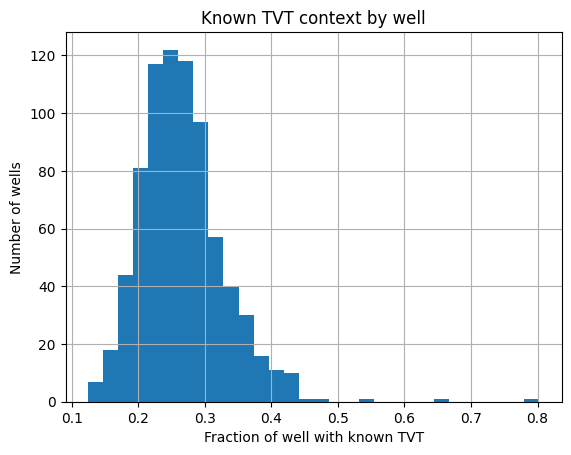

In [16]:
#13. Use mask for na values
hz_train["prediction_zone"] = hz_train["TVT_input"].isna()
hz_test["prediction_zone"] = hz_test["TVT_input"].isna()
print(
    hz_train["prediction_zone"]
    .value_counts()
)

print(
    hz_test["prediction_zone"]
    .value_counts()
)

known_fraction = (
    hz_train
    .assign(known=hz_train["TVT_input"].notna())
    .groupby("well_id")["known"]
    .mean()
)

display(known_fraction.describe())

known_fraction.hist(bins=30)

plt.xlabel("Fraction of well with known TVT")
plt.ylabel("Number of wells")
plt.title("Known TVT context by well")
plt.show()

In [17]:
#14. Validate TVT_input structure
def has_single_prediction_transition(s):
    missing = s.isna().to_numpy()

    if not missing.any():
        return True

    first_missing = np.argmax(missing)

    return missing[first_missing:].all()

valid_tvt_structure = (
    hz_train
    .groupby("well_id")["TVT_input"]
    .apply(has_single_prediction_transition)
)

print(valid_tvt_structure.value_counts())

TVT_input
True    773
Name: count, dtype: int64


In [18]:
#16. Check whether TVT_input matches TVT
known_rows = hz_train["TVT_input"].notna()

difference = (
    hz_train.loc[known_rows, "TVT_input"]
    - hz_train.loc[known_rows, "TVT"]
)

print(difference.describe())
print("Maximum absolute difference:", difference.abs().max())

mismatches = difference.abs() > 1e-6

print("Mismatched rows:", mismatches.sum())

count    1308266.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
dtype: float64
Maximum absolute difference: 0.0
Mismatched rows: 0


count    816205.000000
mean          1.847541
std           2.310610
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         331.000000
Name: GR, dtype: float64

0.500      1.0
0.900      3.0
0.990      9.0
0.999     17.0
1.000    331.0
Name: GR, dtype: float64

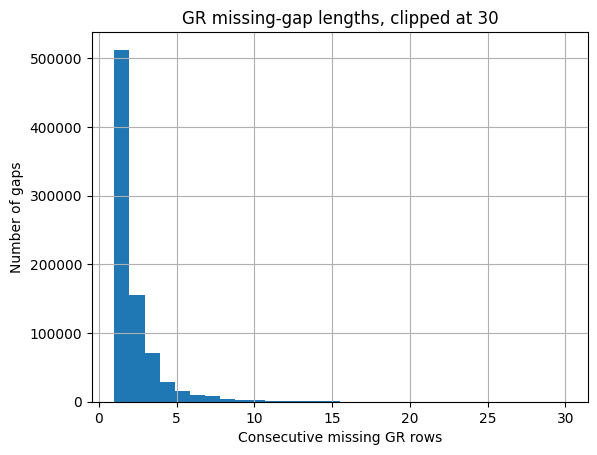

In [19]:
#17 GR missing-gap analysis
def na_run_lengths(s):
    is_na = s.isna()

    run_id = (
        is_na != is_na.shift()
    ).cumsum()

    lengths = is_na.groupby(run_id).sum()

    return lengths[lengths > 0]

gr_gaps = (
    hz_train
    .groupby("well_id")["GR"]
    .apply(na_run_lengths)
)

display(gr_gaps.describe())

display(
    gr_gaps.quantile([
        0.50,
        0.90,
        0.99,
        0.999,
        1.00
    ])
)

gr_gaps.clip(upper=30).hist(bins=30)

plt.xlabel("Consecutive missing GR rows")
plt.ylabel("Number of gaps")
plt.title("GR missing-gap lengths, clipped at 30")
plt.show()

In [20]:
#18a. Check wells with no GR data
gr_availability = (
    hz_train
    .groupby("well_id")["GR"]
    .agg(
        rows="size",
        available=lambda x: x.notna().sum(),
        missing=lambda x: x.isna().sum()
    )
)

gr_availability["missing_percent"] = (
    gr_availability["missing"]
    / gr_availability["rows"]
    * 100
)

display(
    gr_availability
    .sort_values("available")
    .head(20)
)

,rows,available,missing,missing_percent
well_id,,,,
aed44918,4020,1377,2643,65.746269
2be5c96a,5753,1555,4198,72.970624
c36625df,6386,1616,4770,74.694645
8b95d6d1,2783,1663,1120,40.244341
86454a6f,9100,1811,7289,80.098901
512943b2,6681,1814,4867,72.848376
5aef5c6c,4853,1853,3000,61.817433
e14d641e,4978,1883,3095,62.173564
283269ac,4567,1891,2676,58.594263


In [21]:
#18b. Find fully missing GR wells
fully_missing_gr = gr_availability[
    gr_availability["available"] == 0
]

print("Wells with entirely missing GR:", len(fully_missing_gr))
display(fully_missing_gr)

Wells with entirely missing GR: 0


,rows,available,missing,missing_percent
well_id,,,,


In [22]:
#19. MD Spacing
md_steps = (
    hz_train
    .sort_values(["well_id", "MD"])
    .groupby("well_id")["MD"]
    .diff()
)

display(md_steps.describe())
display(md_steps.value_counts().head(10))

count    5091482.0
mean           1.0
std            0.0
min            1.0
25%            1.0
50%            1.0
75%            1.0
max            1.0
Name: MD, dtype: float64

MD
1.0    5091482
Name: count, dtype: int64

In [23]:
#20. Analyze TVT Changes
hz_train = hz_train.sort_values(
    ["well_id", "MD"]
).copy()

hz_train["dTVT"] = (
    hz_train
    .groupby("well_id")["TVT"]
    .diff()
)

display(hz_train["dTVT"].describe())

display(
    hz_train["dTVT"]
    .abs()
    .quantile([
        0.50,
        0.90,
        0.99,
        0.999,
        1.00
    ])
)

count    5.091482e+06
mean     1.089360e-01
std      2.962713e-01
min     -1.513800e+02
25%     -1.000000e-02
50%      0.000000e+00
75%      3.000000e-02
max      1.561000e+01
Name: dTVT, dtype: float64

0.500      0.02
0.900      0.58
0.990      1.07
0.999      1.57
1.000    151.38
Name: dTVT, dtype: float64

well_id
3c3dbcbc    151.38
ccedb12b     15.61
466fc788     13.97
1d3fbf02     13.71
173ed841     12.92
eb640a35     12.91
e201fd6d     10.22
925a7cd1      9.89
7271dd80      9.74
00bbac68      9.27
d90aa14c      9.10
c2c6fc71      8.70
94467f50      8.28
084d66f9      8.19
fc03f21f      8.17
059c8f24      8.13
389ae58f      8.10
0dc5e64d      7.94
2ac7cb6b      7.75
c2c4db09      7.73
Name: TVT, dtype: float64

Wells with TVT jumps greater than 10 ft: 7


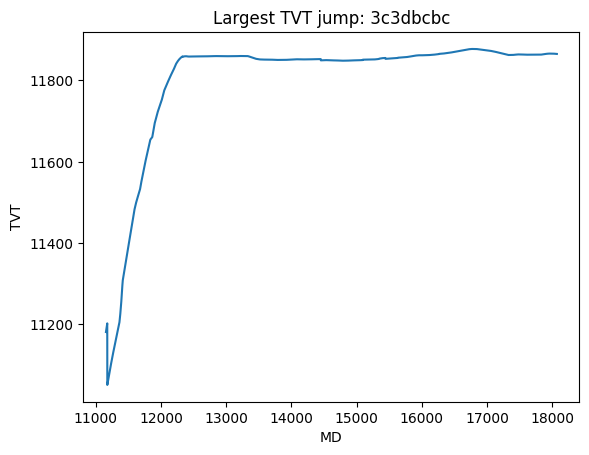

In [24]:
#21. Get the largest TVT jumps by well
max_tvt_jump = (
    hz_train
    .groupby("well_id")["TVT"]
    .apply(lambda s: s.diff().abs().max())
    .sort_values(ascending=False)
)

display(max_tvt_jump.head(20))

print(
    "Wells with TVT jumps greater than 10 ft:",
    (max_tvt_jump > 10).sum()
)

worst_well_id = max_tvt_jump.idxmax()

worst_well = (
    hz_train[
        hz_train["well_id"] == worst_well_id
    ]
    .sort_values("MD")
)

plt.plot(
    worst_well["MD"],
    worst_well["TVT"]
)

plt.xlabel("MD")
plt.ylabel("TVT")
plt.title(f"Largest TVT jump: {worst_well_id}")
plt.show()

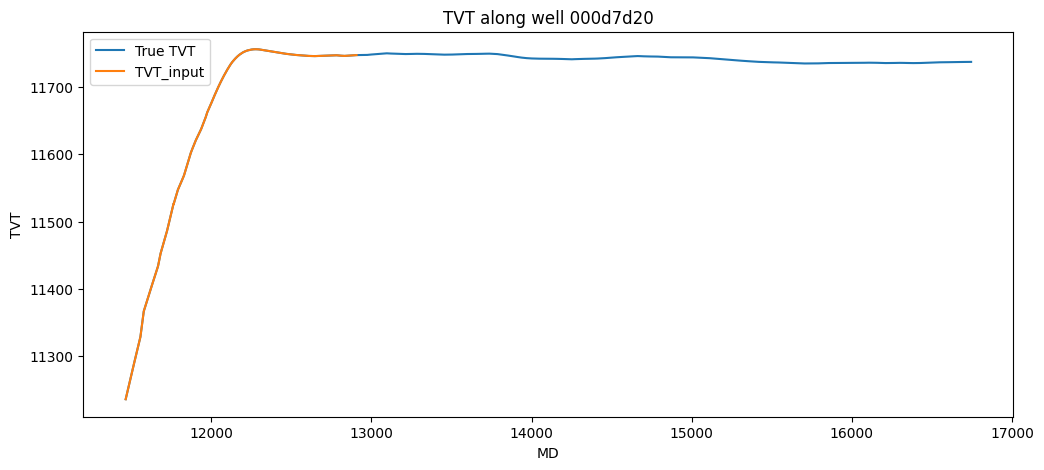

In [25]:
#22. Look at one complete well
example_well_id = hz_train["well_id"].iloc[0]

well = (
    hz_train[
        hz_train["well_id"] == example_well_id
    ]
    .sort_values("MD")
)

plt.figure(figsize=(12, 5))

plt.plot(
    well["MD"],
    well["TVT"],
    label="True TVT"
)

plt.plot(
    well["MD"],
    well["TVT_input"],
    label="TVT_input"
)

plt.xlabel("MD")
plt.ylabel("TVT")
plt.title(f"TVT along well {example_well_id}")
plt.legend()
plt.show()

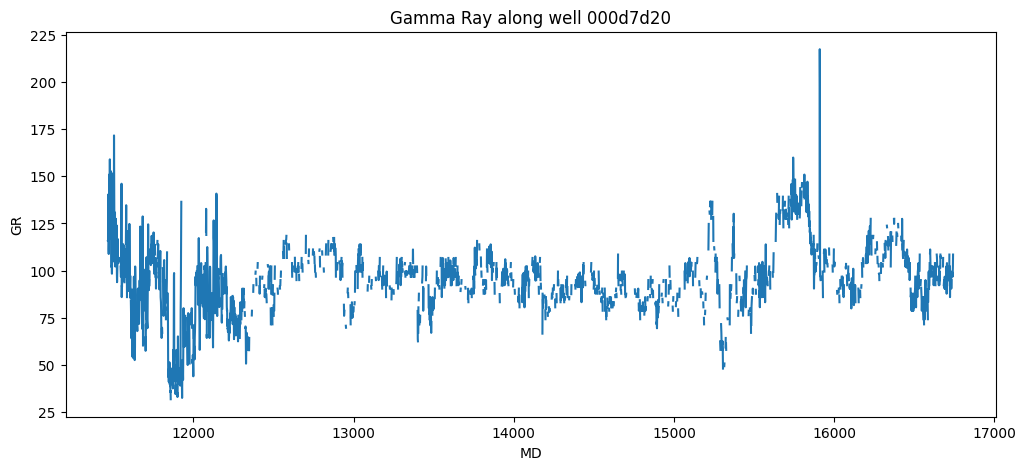

In [26]:
#23. Plot GR along measured depth
plt.figure(figsize=(12, 5))

plt.plot(
    well["MD"],
    well["GR"]
)

plt.xlabel("MD")
plt.ylabel("GR")
plt.title(f"Gamma Ray along well {example_well_id}")
plt.show()

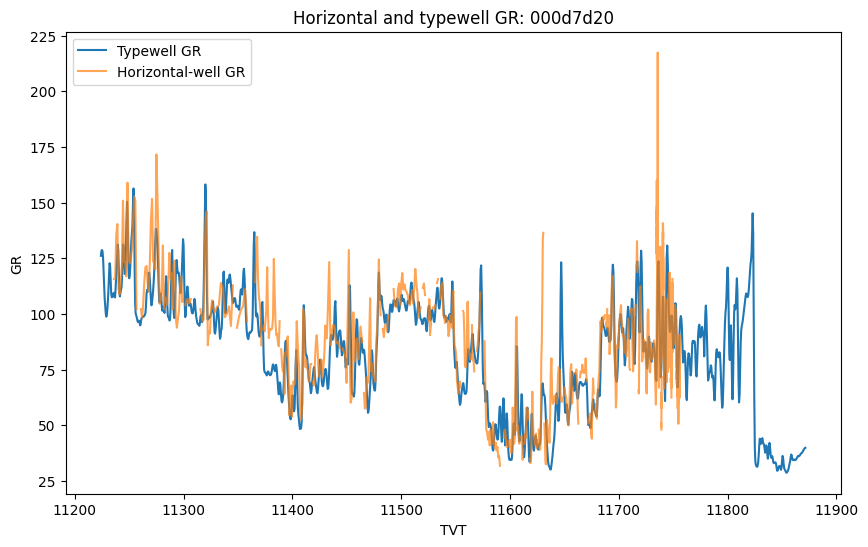

In [27]:
#24. Compare horizontal GR with typewell GR
typewell = (
    tw_train[
        tw_train["well_id"] == example_well_id
    ]
    .sort_values("TVT")
)
plt.figure(figsize=(10, 6))

plt.plot(
    typewell["TVT"],
    typewell["GR"],
    label="Typewell GR"
)

plt.plot(
    well["TVT"],
    well["GR"],
    label="Horizontal-well GR",
    alpha=0.7
)

plt.xlabel("TVT")
plt.ylabel("GR")
plt.title(f"Horizontal and typewell GR: {example_well_id}")
plt.legend()
plt.show()

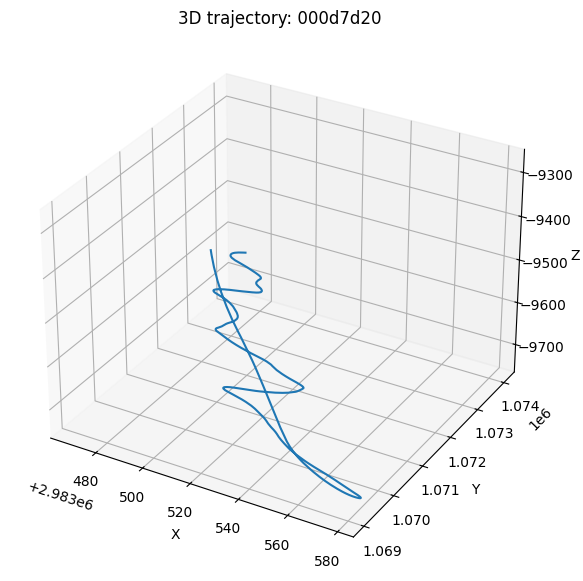

In [28]:
#25. Typewell 3D well trajectory
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.plot(
    well["X"],
    well["Y"],
    well["Z"]
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"3D trajectory: {example_well_id}")

plt.show()

In [29]:
#26. Examine coordinate changes
hz_train["dX"] = (
    hz_train
    .groupby("well_id")["X"]
    .diff()
)

hz_train["dY"] = (
    hz_train
    .groupby("well_id")["Y"]
    .diff()
)

hz_train["dZ"] = (
    hz_train
    .groupby("well_id")["Z"]
    .diff()
)

display(
    hz_train[
        ["dX", "dY", "dZ"]
    ].describe()
)

,dX,dY,dZ
count,5.091482e+06,5.091482e+06,5.091482e+06
mean,-6.043206e-02,1.060606e-01,-1.031249e-01
std,5.066927e-01,7.995961e-01,2.800398e-01
min,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,-5.900000e-01,-7.600000e-01,-5.000000e-02
50%,-5.000000e-02,6.400000e-01,-1.000000e-02
75%,3.900000e-01,8.100000e-01,3.000000e-02
max,9.800000e-01,1.000000e+00,1.800000e-01


In [30]:
#27. Calculate horizontal direction and inclination features
hz_train["horizontal_step"] = np.sqrt(
    hz_train["dX"] ** 2
    + hz_train["dY"] ** 2
)
hz_train["trajectory_step"] = np.sqrt(
    hz_train["dX"] ** 2
    + hz_train["dY"] ** 2
    + hz_train["dZ"] ** 2
)

hz_train["azimuth"] = np.arctan2(
    hz_train["dY"],
    hz_train["dX"]
)

hz_train["trajectory_slope"] = (
    hz_train["dZ"]
    / hz_train["horizontal_step"].replace(0, np.nan)
)

In [31]:
#28. Train/Test feature comparison
train_only_columns = (
    set(hz_train.columns)
    - set(hz_test.columns)
)

test_only_columns = (
    set(hz_test.columns)
    - set(hz_train.columns)
)

print("Train-only columns:", train_only_columns)
print("Test-only columns:", test_only_columns)

Train-only columns: {'horizontal_step', 'TVT', 'dTVT', 'dZ', 'ASTNU', 'dX', 'dY', 'BUDA', 'ANCC', 'EGFDU', 'trajectory_slope', 'azimuth', 'trajectory_step', 'ASTNL', 'EGFDL'}
Test-only columns: set()


In [32]:
#29. Compare train and test distributions
shared_cols = [
    "MD",
    "X",
    "Y",
    "Z",
    "GR"
]

comparison = []

for col in shared_cols:
    comparison.append({
        "feature": col,
        "train_mean": hz_train[col].mean(),
        "test_mean": hz_test[col].mean(),
        "train_std": hz_train[col].std(),
        "test_std": hz_test[col].std(),
        "train_missing_pct": hz_train[col].isna().mean() * 100,
        "test_missing_pct": hz_test[col].isna().mean() * 100
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,feature,train_mean,test_mean,train_std,test_std,train_missing_pct,test_missing_pct
0,MD,1.431686e+04,1.444556e+04,2206.523850,2051.403659,0.00000,0.000000
1,X,2.965999e+06,2.988709e+06,47749.981497,16865.398448,0.00000,0.000000
2,Y,1.074748e+06,1.074573e+06,35603.540240,10628.101791,0.00000,0.000000
3,Z,-9.390812e+03,-9.665867e+03,634.475915,394.946757,0.00000,0.000000
4,GR,8.775241e+01,7.645979e+01,23.768335,30.490246,29.61305,19.686801


In [33]:
#30. GR Preprocessing
gr_mean = hz_train["GR"].mean()
gr_std = hz_train["GR"].std()

print("GR mean:", gr_mean)
print("GR standard deviation:", gr_std)

def prepare_gr(df, mean, std):
    df = df.copy()

    df["GR_missing"] = (
        df["GR"]
        .isna()
        .astype("float32")
    )

    df["GR_z"] = (
        df["GR"] - mean
    ) / std

    df["GR_z"] = (
        df
        .groupby("well_id")["GR_z"]
        .transform(
            lambda s: s.interpolate(
                method="linear",
                limit=16,
                limit_area="inside"
            )
        )
    )

    df["GR_z"] = df["GR_z"].fillna(0.0)

    return df

hz_train = prepare_gr(
    hz_train,
    gr_mean,
    gr_std
)

hz_test = prepare_gr(
    hz_test,
    gr_mean,
    gr_std
)

GR mean: 87.75241378924953
GR standard deviation: 23.768335469211756


In [34]:
#31. Prepare each well as a separate sequence
trajectory_stats = (
    hz_train
    .groupby("well_id")[["X", "Y", "Z"]]
    .diff()
    .std()
)

STATS = {
    "gr_mean": gr_mean,
    "gr_std": gr_std,
    "dx_std": trajectory_stats["X"],
    "dy_std": trajectory_stats["Y"],
    "dz_std": trajectory_stats["Z"]
}

def prepare_well(df, stats, has_target=True):
    df = df.sort_values("MD").copy()

    df["GR_missing"] = (
        df["GR"].isna().astype("float32")
    )

    df["GR_z"] = (
        df["GR"] - stats["gr_mean"]
    ) / stats["gr_std"]

    df["GR_z"] = (
        df["GR_z"]
        .interpolate(
            method="linear",
            limit=16,
            limit_area="inside"
        )
        .fillna(0.0)
    )

    df["dX_z"] = (
        df["X"].diff().fillna(0)
        / stats["dx_std"]
    )

    df["dY_z"] = (
        df["Y"].diff().fillna(0)
        / stats["dy_std"]
    )

    df["dZ_z"] = (
        df["Z"].diff().fillna(0)
        / stats["dz_std"]
    )

    if has_target:
        df["dTVT"] = (
            df["TVT"]
            .diff()
            .fillna(0)
        )

    return df

train_wells = {
    well_id: prepare_well(
        group,
        STATS,
        has_target=True
    )
    for well_id, group
    in hz_train.groupby("well_id")
}

test_wells = {
    well_id: prepare_well(
        group,
        STATS,
        has_target=False
    )
    for well_id, group
    in hz_test.groupby("well_id")
}

In [35]:
#32. Split train and validation well
# Since this data is sequential, don't do random split
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

all_well_ids = np.array(
    list(train_wells.keys())
)

rng.shuffle(all_well_ids)

n_validation = int(
    0.15 * len(all_well_ids)
)

val_ids = all_well_ids[:n_validation]
train_ids = all_well_ids[n_validation:]

print("Training wells:", len(train_ids))
print("Validation wells:", len(val_ids))

Training wells: 658
Validation wells: 115


In [36]:
from torch.utils.data import Dataset

#33. Create a Dataset class
class WellDataset(Dataset):
    def __init__(
        self,
        wells,
        well_ids,
        train=True,
        min_context_fraction=0.10,
        max_context_fraction=0.60
    ):
        self.wells = wells
        self.well_ids = list(well_ids)
        self.train = train
        self.min_context_fraction = min_context_fraction
        self.max_context_fraction = max_context_fraction

    def __len__(self):
        return len(self.well_ids)

    def __getitem__(self, index):
        well_id = self.well_ids[index]

        df = (
            self.wells[well_id]
            .sort_values("MD")
            .reset_index(drop=True)
        )

        sequence_length = len(df)

        if self.train:
            fraction = np.random.uniform(
                self.min_context_fraction,
                self.max_context_fraction
            )

            split = int(fraction * sequence_length)

            split = max(
                1,
                min(split, sequence_length - 2)
            )

        else:
            known_positions = np.flatnonzero(
                df["TVT_input"].notna().to_numpy()
            )

            if len(known_positions) == 0:
                raise ValueError(
                    f"Well {well_id} has no known TVT_input values."
                )

            split = int(known_positions.max())

        positions = np.arange(sequence_length)

        is_context = (
            positions <= split
        ).astype(np.float32)

        prediction_mask = (
            positions > split
        ).astype(np.float32)

        dtvt = df["dTVT"].to_numpy(
            dtype=np.float32
        )

        dtvt_context = np.where(
            is_context == 1,
            dtvt,
            0.0
        ).astype(np.float32)

        feature_columns = [
            "GR_z",
            "GR_missing",
            "dX_z",
            "dY_z",
            "dZ_z"
        ]

        static_features = (
            df[feature_columns]
            .to_numpy(dtype=np.float32)
        )

        x = np.column_stack([
            static_features,
            dtvt_context,
            is_context
        ]).astype(np.float32)

        tvt = df["TVT"].to_numpy(
            dtype=np.float32
        )

        anchor = np.float32(
            tvt[split]
        )

        return {
            "x": torch.from_numpy(x),
            "dtvt": torch.from_numpy(dtvt),
            "tvt": torch.from_numpy(tvt),
            "mask": torch.from_numpy(prediction_mask),
            "anchor": torch.tensor(anchor),
            "length": sequence_length,
            "well_id": well_id
        }

In [37]:
#34: Create a padding function
def collate(batch):
    batch_size = len(batch)

    max_length = max(
        item["length"]
        for item in batch
    )

    feature_count = batch[0]["x"].shape[1]

    x = torch.zeros(
        batch_size,
        max_length,
        feature_count
    )

    dtvt = torch.zeros(
        batch_size,
        max_length
    )

    tvt = torch.zeros(
        batch_size,
        max_length
    )

    mask = torch.zeros(
        batch_size,
        max_length
    )

    pad = torch.zeros(
        batch_size,
        max_length
    )

    anchor = torch.zeros(batch_size)

    well_ids = []

    for i, item in enumerate(batch):
        length = item["length"]

        x[i, :length] = item["x"]
        dtvt[i, :length] = item["dtvt"]
        tvt[i, :length] = item["tvt"]
        mask[i, :length] = item["mask"]

        # 1 means a real row.
        pad[i, :length] = 1.0

        anchor[i] = item["anchor"]
        well_ids.append(item["well_id"])

    return {
        "x": x,
        "dtvt": dtvt,
        "tvt": tvt,
        "mask": mask,
        "pad": pad,
        "anchor": anchor,
        "well_id": well_ids
    }

In [38]:
#35: Create a dataloader
train_dl = DataLoader(
    WellDataset(
        train_wells,
        train_ids,
        train=True
    ),
    batch_size=1,
    shuffle=True,
    collate_fn=collate,
    num_workers=2
)

val_dl = DataLoader(
    WellDataset(
        train_wells,
        val_ids,
        train=False
    ),
    batch_size=1,
    shuffle=False,
    collate_fn=collate,
    num_workers=2
)

In [39]:
#36. Test one batch
batch = next(iter(train_dl))

for key, value in batch.items():
    if isinstance(value, torch.Tensor):
        print(key, value.shape)
    else:
        print(key, type(value))

x torch.Size([1, 6669, 7])
dtvt torch.Size([1, 6669])
tvt torch.Size([1, 6669])
mask torch.Size([1, 6669])
pad torch.Size([1, 6669])
anchor torch.Size([1])
well_id <class 'list'>


In [40]:
#37. Check the device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

Using: cuda


In [41]:
import torch.nn as nn
# 38. build a Transformer model
class SimpleWellTransformer(nn.Module):
    def __init__(
        self,
        input_dim=7,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        max_len=4096
    ):
        super().__init__()

        # 1. Convert 7 raw features into d_model dimensions
        self.input_projection = nn.Linear(
            input_dim,
            d_model
        )

        # 2. Learn a position vector for each sequence position
        self.position_embedding = nn.Embedding(
            max_len,
            d_model
        )

        # 3. Define one encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True
        )

        # 4. Stack encoder layers
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # 5. Predict one dTVT value per row
        self.output_layer = nn.Linear(
            d_model,
            1
        )

    def forward(self, x, padding_mask=None):
        """
        x shape:
            (batch_size, sequence_length, input_dim)

        padding_mask shape:
            (batch_size, sequence_length)

        padding_mask:
            False = real row
            True = padded row
        """

        sequence_length = x.shape[1]

        positions = torch.arange(
            sequence_length,
            device=x.device
        )

        x = self.input_projection(x)

        position_vectors = self.position_embedding(
            positions
        )

        x = x + position_vectors.unsqueeze(0)

        x = self.encoder(
            x,
            src_key_padding_mask=padding_mask
        )

        predictions = self.output_layer(x)

        predictions = predictions.squeeze(-1)

        return predictions

In [42]:
#39. Initiate and assign Transformer hyperparameters
INPUT_DIM = 7
D_MODEL = 64
NHEAD = 4
NUM_LAYERS = 2
DIM_FEEDFORWARD = 128
DROPOUT = 0.1
MAX_LEN = max(
    len(df)
    for df in train_wells.values()
)

In [43]:
# 40. Initiate the model
model = SimpleWellTransformer(
    input_dim=INPUT_DIM,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    max_len=MAX_LEN
)

In [44]:
# 41. Run the model and choose the device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [45]:
# 42. Test a single forward pass
batch = next(iter(train_dl))

x = batch["x"].to(device)

padding_mask = (
    batch["pad"].to(device) == 0
)

print("Input shape:", x.shape)
print("Padding mask shape:", padding_mask.shape)

Input shape: torch.Size([1, 4728, 7])
Padding mask shape: torch.Size([1, 4728])


In [46]:
# 43. Run the model
model.eval()

with torch.no_grad():
    dtvt_predictions = model(
        x=x,
        padding_mask=padding_mask
    )

print("Prediction shape:", dtvt_predictions.shape)

Prediction shape: torch.Size([1, 4728])


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


In [47]:
# 44. Reconsruct absolute TVT
def reconstruct_tvt(
    dtvt_predictions,
    anchor,
    prediction_mask
):
    # Keep predictions only in the prediction region
    predicted_changes = (
        dtvt_predictions * prediction_mask
    )

    # Cumulative sum of predicted changes
    cumulative_changes = torch.cumsum(
        predicted_changes,
        dim=1
    )

    # Add the last known TVT value
    tvt_predictions = (
        anchor.unsqueeze(1)
        + cumulative_changes
    )

    return tvt_predictions


In [48]:
# 45. Reconstruct absolute TVT 
prediction_mask = batch["mask"].to(device)
anchor = batch["anchor"].to(device)

with torch.no_grad():
    tvt_predictions = reconstruct_tvt(
        dtvt_predictions=dtvt_predictions,
        anchor=anchor,
        prediction_mask=prediction_mask
    )

print("TVT prediction shape:", tvt_predictions.shape)

TVT prediction shape: torch.Size([1, 4728])


In [49]:
#46. Define masked_rmse()
def masked_rmse(predictions, targets, mask):
    squared_errors = (predictions - targets) ** 2

    masked_squared_errors = squared_errors * mask

    mse = (
        masked_squared_errors.sum()
        / mask.sum().clamp_min(1.0)
    )

    return torch.sqrt(mse)

In [50]:
# 47. Calculate RMSE for the current batch
true_tvt = batch["tvt"].to(device)
prediction_mask = batch["mask"].to(device)

rmse = masked_rmse(
    predictions=tvt_predictions,
    targets=true_tvt,
    mask=prediction_mask
)

print("Initial RMSE:", rmse.item())

Initial RMSE: 263.86181640625


In [53]:
# 48. Define optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4)
print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [54]:
#49. Train for one epoch

def train_one_epoch(
    model,
    dataloader,
    optimizer,
    device
):
    model.train()

    total_squared_error = 0.0
    total_prediction_rows = 0.0

    for batch in dataloader:

        x = batch["x"].to(device)
        true_tvt = batch["tvt"].to(device)
        prediction_mask = batch["mask"].to(device)
        anchor = batch["anchor"].to(device)

        padding_mask = (
            batch["pad"].to(device) == 0
        )

        optimizer.zero_grad()

        # Predict dTVT
        dtvt_predictions = model(
            x=x,
            padding_mask=padding_mask
        )

        # Reconstruct absolute TVT
        tvt_predictions = reconstruct_tvt(
            dtvt_predictions=dtvt_predictions,
            anchor=anchor,
            prediction_mask=prediction_mask
        )

        # Calculate RMSE
        loss = masked_rmse(
            predictions=tvt_predictions,
            targets=true_tvt,
            mask=prediction_mask
        )

        # Calculate gradients
        loss.backward()

        # Prevent extremely large gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # Update model weights
        optimizer.step()

        squared_error = (
            (tvt_predictions.detach() - true_tvt) ** 2
            * prediction_mask
        ).sum()

        total_squared_error += squared_error.item()
        total_prediction_rows += prediction_mask.sum().item()

    epoch_rmse = (
        total_squared_error
        / max(total_prediction_rows, 1)
    ) ** 0.5

    return epoch_rmse

In [56]:
#50. Run on training epoch
num_epochs = 10

for epoch in range(num_epochs):
    train_rmse = train_one_epoch(
        model=model,
        dataloader=train_dl,
        optimizer=optimizer,
        device=device
    )

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"- Training RMSE: {train_rmse:.4f}"
    )

Epoch 1/10 - Training RMSE: 80.1486
Epoch 2/10 - Training RMSE: 69.9755
Epoch 3/10 - Training RMSE: 60.1385
Epoch 4/10 - Training RMSE: 55.8166
Epoch 5/10 - Training RMSE: 53.4046
Epoch 6/10 - Training RMSE: 54.0834
Epoch 7/10 - Training RMSE: 49.0161
Epoch 8/10 - Training RMSE: 46.1705
Epoch 9/10 - Training RMSE: 47.9006
Epoch 10/10 - Training RMSE: 45.7149


In [57]:
# 51. Dataset for Kaggle test wells

class TestWellDataset(Dataset):
    def __init__(self, wells, well_ids):
        self.wells = wells
        self.well_ids = list(well_ids)

    def __len__(self):
        return len(self.well_ids)

    def __getitem__(self, index):
        well_id = self.well_ids[index]

        df = (
            self.wells[well_id]
            .sort_values("MD")
            .reset_index(drop=True)
        )

        sequence_length = len(df)

        known_positions = np.flatnonzero(
            df["TVT_input"].notna().to_numpy()
        )

        if len(known_positions) == 0:
            raise ValueError(
                f"Well {well_id} has no known TVT_input."
            )

        split = int(known_positions.max())

        positions = np.arange(sequence_length)

        is_context = (
            positions <= split
        ).astype(np.float32)

        prediction_mask = (
            positions > split
        ).astype(np.float32)

        # Calculate known dTVT from TVT_input
        tvt_input = df["TVT_input"].to_numpy(
            dtype=np.float32
        )

        dtvt_context = np.zeros(
            sequence_length,
            dtype=np.float32
        )

        known_tvt = tvt_input[:split + 1]

        dtvt_context[1:split + 1] = np.diff(
            known_tvt
        )

        feature_columns = [
            "GR_z",
            "GR_missing",
            "dX_z",
            "dY_z",
            "dZ_z"
        ]

        static_features = (
            df[feature_columns]
            .to_numpy(dtype=np.float32)
        )

        x = np.column_stack([
            static_features,
            dtvt_context,
            is_context
        ]).astype(np.float32)

        anchor = np.float32(
            tvt_input[split]
        )

        return {
            "x": torch.from_numpy(x),
            "mask": torch.from_numpy(prediction_mask),
            "anchor": torch.tensor(anchor),
            "length": sequence_length,
            "well_id": well_id,
            "row_numbers": torch.arange(sequence_length)
        }

In [58]:
# 52. Padding function for test wells

def test_collate(batch):
    batch_size = len(batch)

    max_length = max(
        item["length"]
        for item in batch
    )

    feature_count = batch[0]["x"].shape[1]

    x = torch.zeros(
        batch_size,
        max_length,
        feature_count
    )

    mask = torch.zeros(
        batch_size,
        max_length
    )

    pad = torch.zeros(
        batch_size,
        max_length
    )

    anchor = torch.zeros(batch_size)

    well_ids = []
    lengths = []

    for i, item in enumerate(batch):
        length = item["length"]

        x[i, :length] = item["x"]
        mask[i, :length] = item["mask"]
        pad[i, :length] = 1.0
        anchor[i] = item["anchor"]

        well_ids.append(item["well_id"])
        lengths.append(length)

    return {
        "x": x,
        "mask": mask,
        "pad": pad,
        "anchor": anchor,
        "well_id": well_ids,
        "length": lengths
    }

In [59]:
# 53. Create test DataLoader

test_ids = sorted(test_wells.keys())

test_dataset = TestWellDataset(
    wells=test_wells,
    well_ids=test_ids
)

test_dl = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=test_collate,
    num_workers=2
)

print("Number of test wells:", len(test_dataset))

Number of test wells: 3


In [60]:
# 54. Generate Kaggle test predictions

model.eval()

submission_rows = []

with torch.no_grad():

    for batch in test_dl:

        x = batch["x"].to(device)
        prediction_mask = batch["mask"].to(device)
        anchor = batch["anchor"].to(device)

        padding_mask = (
            batch["pad"].to(device) == 0
        )

        dtvt_predictions = model(
            x=x,
            padding_mask=padding_mask
        )

        tvt_predictions = reconstruct_tvt(
            dtvt_predictions=dtvt_predictions,
            anchor=anchor,
            prediction_mask=prediction_mask
        )

        well_id = batch["well_id"][0]
        length = batch["length"][0]

        predictions = (
            tvt_predictions[0, :length]
            .cpu()
            .numpy()
        )

        mask = (
            prediction_mask[0, :length]
            .cpu()
            .numpy()
            .astype(bool)
        )

        prediction_rows = np.flatnonzero(mask)

        for row_number in prediction_rows:
            submission_rows.append({
                "id": f"{well_id}_{row_number}",
                "tvt": float(predictions[row_number])
            })

In [61]:
# 55. Create submission DataFrame

submission = pd.DataFrame(
    submission_rows,
    columns=["id", "tvt"]
)

print(submission.shape)
display(submission.head())

print(
    "Missing predictions:",
    submission["tvt"].isna().sum()
)

print(
    "Duplicate IDs:",
    submission["id"].duplicated().sum()
)

(14151, 2)


,id,tvt
0,000d7d20_1442,11746.562500
1,000d7d20_1443,11746.230469
2,000d7d20_1444,11746.074219
3,000d7d20_1445,11745.826172
4,000d7d20_1446,11745.642578


Missing predictions: 0
Duplicate IDs: 0


In [63]:
# 56. Find and load the sample submission

sample_files = glob.glob(
    "/kaggle/input/**/sample_submission.csv",
    recursive=True
)

print("Found files:", sample_files)

sample_path = sample_files[0]
sample_submission = pd.read_csv(sample_path)

print("Using:", sample_path)
print("Sample shape:", sample_submission.shape)
print("Our shape:", submission.shape)

missing_ids = (
    set(sample_submission["id"])
    - set(submission["id"])
)

extra_ids = (
    set(submission["id"])
    - set(sample_submission["id"])
)

print("Missing IDs:", len(missing_ids))
print("Extra IDs:", len(extra_ids))

Found files: ['/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv']
Using: /kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
Sample shape: (14151, 2)
Our shape: (14151, 2)
Missing IDs: 0
Extra IDs: 0


In [64]:
# 57. Match Kaggle's required row order

submission = (
    sample_submission[["id"]]
    .merge(
        submission,
        on="id",
        how="left"
    )
)

print(
    "Missing predictions after merge:",
    submission["tvt"].isna().sum()
)

display(submission.head())

Missing predictions after merge: 0


,id,tvt
0,000d7d20_1442,11746.562500
1,000d7d20_1443,11746.230469
2,000d7d20_1444,11746.074219
3,000d7d20_1445,11745.826172
4,000d7d20_1446,11745.642578


In [65]:
# 58. Save submission.csv

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

print("Saved submission.csv")
print(submission.shape)

Saved submission.csv
(14151, 2)
